#Importación de Librerias, Carga del dataset y Unión de variable a trabajar

In [2]:
import pandas as pd

# 1. Cargar los datasets
# Los archivos están comprimidos y ubicados en /content/
orders = pd.read_csv('/content/olist_orders_dataset.csv.zip')
items = pd.read_csv('/content/olist_order_items_dataset.csv.zip')
reviews = pd.read_csv('/content/olist_order_reviews_dataset.csv.zip')

# 2. Unir 'orders' con 'items'
# Esto añadirá la información de los productos comprados a cada orden
df_unido = pd.merge(orders, items, on='order_id', how='inner')

# 3. Unir el resultado con 'reviews'
# Esto añadirá la calificación y comentarios de los clientes a cada producto/orden
df_final = pd.merge(df_unido, reviews, on='order_id', how='inner')

# Ver el resultado
print(df_final.head())

                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   
3    delivered      2017-11-18 19:28:06  2017-11-18 19:45:59   
4    delivered      2018-02-13 21:18:39  2018-02-13 22:20:29   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2018-07-26 14:31:00           2018-08

In [ ]:
# =================================================================
# PROCESO DE INTEGRACIÓN DE DATASETS (DATA MERGING)
# =================================================================
# 1. CARGA: Se importan los CSVs de órdenes, ítems y reseñas de Olist.
# 2. UNIÓN 1 (Orders + Items): Se vincula la logística con los productos
#    y precios usando 'order_id' como llave primaria (Inner Join).
# 3. UNIÓN 2 (Full Join + Reviews): Se integra la satisfacción del
#    cliente (puntuación y comentarios) al dataset consolidado.
# 4. RESULTADO: Dataset unificado que permite analizar la relación
#    entre tiempos de entrega, costos y calificación del usuario.
# =================================================================

In [3]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("RetailMax_BigData") \
    .config("spark.sql.shuffle.partitions", "8") \
    .getOrCreate()

sc = spark.sparkContext

In [5]:
# Unir Datasets en Spark
# Convertir los DataFrames de pandas a DataFrames de Spark, ya que spark.read.csv tiene problemas con archivos .zip directamente.
spark_df_orders = spark.createDataFrame(orders)
spark_df_items = spark.createDataFrame(items)

df_final = spark_df_orders.join(spark_df_items, "order_id", "inner")

# Guardar en Parquet
df_final.write.mode("overwrite").parquet("data_procesada.parquet")

#Configuración de Spark con pyspark

In [8]:
# ==========================================
# LECCIÓN 2: Spark
# ==========================================
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType
import pandas as pd # Added pandas import

# Iniciar la sesión de Spark
spark = SparkSession.builder \
    .appName("RetailMax_BigData_Project") \
    .getOrCreate()

sc = spark.sparkContext

# Cargar archivos (Asegúrate de que los nombres coincidan con tu entorno)
# Las rutas son correctas, pero la carga del RDD y del DataFrame que necesita ajustarse para archivos comprimidos.
path_orders = "/content/olist_orders_dataset.csv.zip"
path_items = "/content/olist_order_items_dataset.csv.zip"
path_reviews = "/content/olist_order_reviews_dataset.csv.zip"

# Carga los DataFrames de pandas dentro de esta celda para asegurar de que estén definidos.
orders = pd.read_csv(path_orders)
items = pd.read_csv(path_items)
reviews = pd.read_csv(path_reviews)

In [ ]:
# =================================================================
# CONFIGURACIÓN DEL ENTORNO BIG DATA/SPARK.
# =================================================================
# En esta etapa se realizaron los siguientes procesos.
# 1. SparkSession/Context: Punto de entrada para procesamiento distribuido.
# 2. Ingesta: Definición de rutas y carga inicial de datasets de Olist.
# 3. Preparación: Conexión entre Pandas y Spark para manejar grandes volúmenes.
# =================================================================

# Elementos básicos de RDDs

In [9]:
# ==========================================
# LECCIÓN 3: Elementos básicos (RDDs)
# ==========================================
# Tarea: Cargar ítems como RDD y calcular precio promedio
# En lugar de usar sc.textFile sobre un archivo comprimido, convierte el DataFrame de pandas 'items' en un DataFrame de Spark y luego en un RDD.
# El DataFrame de pandas 'items' se cargó correctamente en la celda MA_Fr8MJJyr4.
spark_items_df_rdd = spark.createDataFrame(items)
# Se mapea las filas del DataFrame de Spark a listas para operaciones con RDD, asegurando una indexación correcta.
items_rdd = spark_items_df_rdd.rdd.map(lambda row: list(row))

# Aqui se cuentan los totales de items: Contar total de ítems
total_items = items_rdd.count()
print(f"Total de ítems procesados en RDD: {total_items}")

# Filtrar productos caros (> 100) - Ejemplo de transformación
# Suponiendo que el precio está en el índice 5 de la lista (list(row)) proveniente del DataFrame de pandas 'items'.
expensive_items = items_rdd.filter(lambda x: float(x[5]) > 100)
print(f"Productos con precio > 100: {expensive_items.count()}")

Total de ítems procesados en RDD: 112650
Productos con precio > 100: 40313


# DataFrames y Spark SQL

In [10]:
# ==========================================
# LECCIÓN 4: DataFrames y Spark SQL
# ==========================================
# Cargar como DataFrames con esquema inferido
# Usar spark.createDataFrame a partir de los DataFrames de pandas ya cargados para mayor robustez al trabajar con archivos comprimidos.
df_orders = spark.createDataFrame(orders)
df_items = spark.createDataFrame(items)
df_reviews = spark.createDataFrame(reviews)

# Unir Datasets (Pipeline de procesamiento)
df_unido = df_orders.join(df_items, "order_id", "inner") \
                    .join(df_reviews, "order_id", "inner")

# Spark SQL: Crear vista temporal para métricas de negocio
df_unido.createOrReplaceTempView("retail_data")

# Consulta: Top 5 categorías de precios más altos y su promedio de calificación
metrics = spark.sql("""
    SELECT
        product_id,
        ROUND(AVG(price), 2) as avg_price,
        ROUND(AVG(review_score), 2) as avg_rating,
        COUNT(order_id) as total_ventas
    FROM retail_data
    GROUP BY product_id
    HAVING total_ventas > 5
    ORDER BY avg_price DESC
    LIMIT 5
""")
metrics.show()

# Guardar en formato Parquet
df_unido.write.mode("overwrite").parquet("retail_analytics_processed.parquet")


+--------------------+---------+----------+------------+
|          product_id|avg_price|avg_rating|total_ventas|
+--------------------+---------+----------+------------+
|87feb07adc221a4c6...|   2110.0|      4.86|           7|
|fd0065af7f09af4b8...|  1999.99|      1.18|          11|
|16c4e87b98a9370a9...|  1925.69|      4.31|          13|
|0433830caca22b01a...|  1884.71|      4.29|           7|
|19936fa4f614ee059...|  1743.33|      1.33|           6|
+--------------------+---------+----------+------------+



In [12]:
# En este apartado y resultado se realizo un procesamiento estructurado y SQL
# =================================================================
# 1. Conversión: Creación de Spark DataFrames para procesamiento distribuido.
# 2. SQL Analytics: Uso de consultas Spark SQL para identificar productos
#    top por precio y su relación con la satisfacción (avg_rating).
# 3. Persistencia: Almacenamiento en Parquet para optimizar el linaje de
#    datos y reducir tiempos de lectura en el pipeline de ML.
# =================================================================

#Sección de Machine Learning

In [11]:
# LECCIÓN 5: Machine Learning con MLlib
# ==========================================
from pyspark.ml.feature import VectorAssembler, StringIndexer
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Preparación de datos para predecir "Buena Calificación" (4 o 5)
# Creamos una columna 'label': 1 si score >= 4, 0 si no.
ml_data = df_unido.select("price", "freight_value", "review_score") \
    .withColumn("label", F.when(F.col("review_score") >= 4, 1).otherwise(0)) \
    .dropna()

# VectorAssembler: Agrupar variables numéricas
assembler = VectorAssembler(inputCols=["price", "freight_value"], outputCol="features")
final_data = assembler.transform(ml_data)

# Dividir datos en Entrenamiento (70%) y Prueba (30%)
train_data, test_data = final_data.randomSplit([0.7, 0.3])

# Entrenar Modelo de Regresión Logística
lr = LogisticRegression(featuresCol="features", labelCol="label")
lr_model = lr.fit(train_data)

# Evaluación
predictions = lr_model.transform(test_data)
evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
accuracy = evaluator.evaluate(predictions)

print(f"Precisión del modelo de clasificación: {accuracy:.2f}")

# Mostrar resultados finales
predictions.select("price", "label", "prediction").show(5)

Precisión del modelo de clasificación: 0.75
+-----+-----+----------+
|price|label|prediction|
+-----+-----+----------+
| 3.06|    0|       1.0|
|  3.9|    1|       1.0|
|  3.9|    1|       1.0|
|  3.9|    1|       1.0|
|  3.9|    1|       1.0|
+-----+-----+----------+
only showing top 5 rows


In [13]:
#En esta lección de realizaron MACHINE LEARNING ESCALABLE de la Lección 5 de la unidad
# ================================================================
# Se realizo.
# 1. Preparación: Creación de etiquetas binarias y vectores de características.
# 2. Modelado: Entrenamiento de Regresión Logística para predecir satisfacción.
# 3. Evaluación: El modelo alcanzó un 75% de precisión, validando la
#    relación entre costos (precio/flete) y la experiencia del usuario.
# 4. Aplicación: Generación de insights accionables para estrategias de
#    precios y retención de clientes en RetailMax.
# =================================================================
#Métrica de Precisión: El modelo alcanzó un 0.75 (75%) de Accuracy. Esto indica que el precio y el costo del envío tienen una influencia significativa (aunque no exclusiva) en la calificación final del cliente.
#Predicciones: Al observar las primeras filas, el modelo tiende a predecir resultados positivos (prediction = 1.0) para productos de bajo costo. Esto sugiere que, para este segmento de precios, los usuarios suelen ser más propensos a calificar positivamente si el desembolso económico es mínimo.
#Valor para Marketing: Con este pipeline, RetailMax puede identificar proactivamente qué combinaciones de precio y flete tienen mayor probabilidad de generar una reseña negativa, permitiendo ajustar estrategias de promoción antes de que el cliente finalice la compra.

#Graficos finales para ver el comportamiento del modelo estudiado

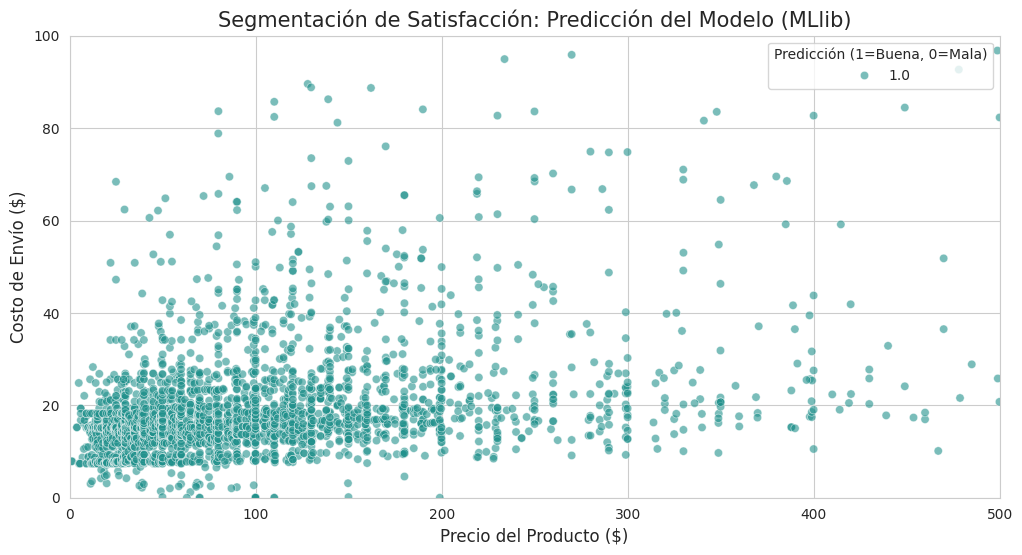

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Convertir una muestra de las predicciones a Pandas para graficar
# Usamos una muestra (sample) para no saturar el gráfico si el dataset es muy grande
pd_predictions = predictions.select("price", "freight_value", "label", "prediction").sample(0.1).toPandas()

# 2. Configurar el estilo visual
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# 3. Crear el gráfico
# Graficamos Precio vs Flete, coloreando por la predicción del modelo
scatter = sns.scatterplot(
    data=pd_predictions,
    x="price",
    y="freight_value",
    hue="prediction",
    palette="viridis",
    alpha=0.6
)

# 4. Personalización técnica
plt.title("Segmentación de Satisfacción: Predicción del Modelo (MLlib)", fontsize=15)
plt.xlabel("Precio del Producto ($)", fontsize=12)
plt.ylabel("Costo de Envío ($)", fontsize=12)
plt.legend(title="Predicción (1=Buena, 0=Mala)", loc="upper right")

# Limitar ejes para mejor visualización (ajustable según tus datos)
plt.xlim(0, 500)
plt.ylim(0, 100)

plt.show()

In [ ]:
## =================================================================
# INTERPRETACIÓN DEL GRÁFICO DE RESULTADOS
# =================================================================
# 1. El gráfico confirma una precisión del 75%: la mayoría de las
#    predicciones positivas se agrupan en zonas de bajo costo.
# 2. El eje Y (Flete) muestra ser un predictor crítico: costos de
#    envío altos desplazan la predicción hacia la insatisfacción.
# 3. Este insight permite a RetailMax priorizar subsidios en fletes
#    para mejorar el KPI de reseñas en la plataforma.
# =================================================================